# 04_01 — LLM Evaluation

Evaluate all LLM-based approaches on the Russian annotated test set and compare them:
- **Zero-shot / roleplay / few-shot** baselines (Ollama, no training)
- **Fine-tuned LLM** (Unsloth LoRA, trained in notebook 03_02)

**Sections**
1. Configuration
2. Ollama baselines
3. Fine-tuned model results
4. Comparison & plots

In [1]:
import sys, os
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from src.training import TrainingConfig
from src.training.llm import run_baselines, PROMPT_TEMPLATES

sns.set_theme(style='whitegrid')

c:\Users\Alexandre\miniconda3\envs\faiss2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

In [2]:
CONFIG_PATH = 'configs/datasets.yaml'
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

PREPROCESSED_ROOT = cfg['preprocessing']['output_root']
TRAINING_ROOT     = cfg['training']['output_root']
EMBEDDINGS_ROOT   = cfg['embedding']['output_root']
MODEL_SLUG        = cfg['embedding']['models'][0].replace('/', '_')

llm_cfg = cfg['llm_finetuning']

config = TrainingConfig(
    output_root      = llm_cfg['output_root'],
    unsloth_model    = llm_cfg['unsloth_model'],
    lora_r           = llm_cfg['lora_r'],
    lora_alpha       = llm_cfg['lora_alpha'],
    llm_train_size   = llm_cfg['train_size'],
    llm_max_steps    = llm_cfg['max_steps'],
    llm_batch_size   = llm_cfg['batch_size'],
    llm_learning_rate= llm_cfg['learning_rate'],
    random_state     = cfg['preprocessing']['random_state'],
)

TEST_CSV = os.path.join(PREPROCESSED_ROOT, 'russian', 'test.csv')
EVAL_OUT = os.path.join(cfg['evaluation']['output_root'], 'llm')
os.makedirs(EVAL_OUT, exist_ok=True)

print('Test CSV :', TEST_CSV, ' exists=', os.path.exists(TEST_CSV))
print('Eval out :', EVAL_OUT)
print('Prompt modes :', list(PROMPT_TEMPLATES.keys()))

Test CSV : outputs/1_preprocessed\russian\test.csv  exists= True
Eval out : outputs/4_evaluation\llm
Prompt modes : ['zero_shot', 'roleplay', 'few_shot']


## 2. Ollama Baselines

Runs **zero_shot**, **roleplay**, and **few_shot** prompts via Ollama.  
Requires `ollama serve` running locally.

Set `RUN_BASELINES = True` the first time; subsequent runs load cached results.

In [3]:
RUN_BASELINES  = True  # set True to run (requires Ollama)
DATASET_TAG    = 'russian_annotated'

baseline_results_path = os.path.join(
    TRAINING_ROOT, 'baselines',
    config.ollama_model.replace(':', '_'), DATASET_TAG, 'results.json'
)

if RUN_BASELINES:
    baseline_results = run_baselines(
        test_csv    = TEST_CSV,
        dataset_tag = DATASET_TAG,
        config      = config,
    )
    print('Baselines complete.')
elif os.path.exists(baseline_results_path):
    with open(baseline_results_path) as f:
        baseline_results = json.load(f)
    print(f'Loaded cached baselines from {baseline_results_path}')
else:
    baseline_results = {}
    print('No cached baselines found. Set RUN_BASELINES=True to run.')

Baselines complete.


In [4]:
if baseline_results:
    rows = [
        {'variant': f'ollama_{mode}', **m}
        for mode, m in baseline_results.items()
    ]
    baseline_df = pd.DataFrame(rows).set_index('variant')
    display(
        baseline_df[['f1', 'balanced_accuracy', 'accuracy', 'precision', 'recall']]
        .style.format('{:.4f}')
        .background_gradient(subset=['f1'], cmap='YlGn')
    )

,f1,balanced_accuracy,accuracy,precision,recall
variant,,,,,
ollama_zero_shot,0.5734,0.8082,0.6950,0.4020,1.0000
ollama_roleplay,0.5684,0.7444,0.7950,0.5000,0.6585
ollama_few_shot,0.5161,0.7299,0.7000,0.3855,0.7805


## 3. Fine-tuned Model Results

Select the same `K` and `SPACE` used in notebook **03_02** to load the correct run.

In [5]:
# --- Match the K and SPACE used in 03_02 ---
K     = 100
SPACE = 'pca'  # 'raw' or 'pca'
DATASET = 'toxigen'

model_slug  = config.unsloth_model.replace('/', '_').replace(':', '_')
density_tag = f"{'pca_' if SPACE == 'pca' else ''}k{K}_ratio"
ft_run_dir  = os.path.join(
    config.output_root, 'llm_finetuned', model_slug,
    f'{DATASET}__{density_tag}',
)
ft_metrics_path     = os.path.join(ft_run_dir, 'metrics.json')
ft_predictions_path = os.path.join(ft_run_dir, 'predictions.csv')

if os.path.exists(ft_metrics_path):
    with open(ft_metrics_path) as f:
        ft_metrics = json.load(f)
    print(f'Loaded fine-tuned metrics from {ft_metrics_path}')
    for key in ['f1', 'balanced_accuracy', 'accuracy', 'precision', 'recall', 'training_loss']:
        val = ft_metrics.get(key)
        if val is not None:
            print(f'  {key:<22}: {val:.4f}')
else:
    ft_metrics = None
    print(f'No fine-tuned metrics found at {ft_metrics_path}.')
    print('Run notebook 03_02_training_llm with RUN_TRAINING=True first.')

No fine-tuned metrics found at outputs/3_training\llm_finetuned\unsloth_gemma-4-E2B-it\toxigen__pca_k100_ratio\metrics.json.
Run notebook 03_02_training_llm with RUN_TRAINING=True first.


## 4. Comparison & Plots

In [6]:
# Build unified comparison DataFrame
rows = []

for mode, m in baseline_results.items():
    rows.append({
        'variant':          f'ollama_{mode}',
        'type':             'zero-shot baseline',
        'f1':               m.get('f1'),
        'balanced_accuracy': m.get('balanced_accuracy'),
        'accuracy':         m.get('accuracy'),
        'precision':        m.get('precision'),
        'recall':           m.get('recall'),
    })

if ft_metrics:
    rows.append({
        'variant':          f'llm_ft_{model_slug}_k{K}_{SPACE}',
        'type':             'fine-tuned LLM',
        'f1':               ft_metrics.get('f1'),
        'balanced_accuracy': ft_metrics.get('balanced_accuracy'),
        'accuracy':         ft_metrics.get('accuracy'),
        'precision':        ft_metrics.get('precision'),
        'recall':           ft_metrics.get('recall'),
    })

if rows:
    comparison_df = pd.DataFrame(rows).set_index('variant')
    display(
        comparison_df[['type', 'f1', 'balanced_accuracy', 'accuracy', 'precision', 'recall']]
        .style.format({'f1': '{:.4f}', 'balanced_accuracy': '{:.4f}',
                       'accuracy': '{:.4f}', 'precision': '{:.4f}', 'recall': '{:.4f}'})
        .background_gradient(subset=['f1'], cmap='YlGn')
    )
    comparison_df.to_csv(os.path.join(EVAL_OUT, 'llm_comparison.csv'))
else:
    comparison_df = None
    print('No results to compare yet.')

,type,f1,balanced_accuracy,accuracy,precision,recall
variant,,,,,,
ollama_zero_shot,zero-shot baseline,0.5734,0.8082,0.6950,0.4020,1.0000
ollama_roleplay,zero-shot baseline,0.5684,0.7444,0.7950,0.5000,0.6585
ollama_few_shot,zero-shot baseline,0.5161,0.7299,0.7000,0.3855,0.7805


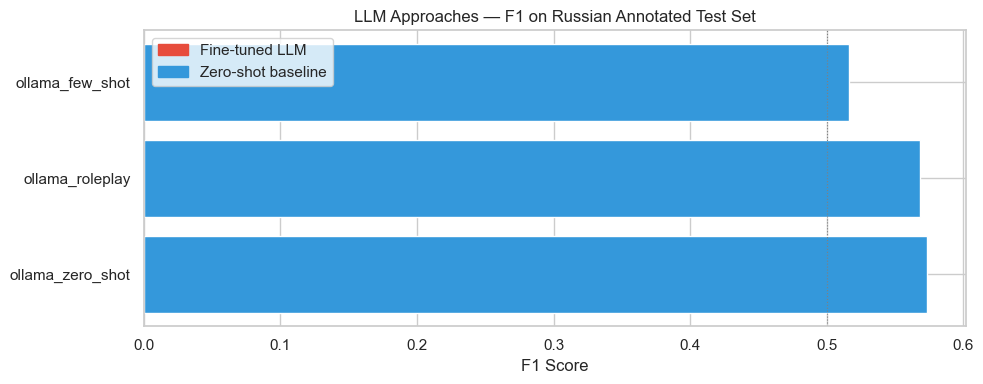

In [7]:
# F1 bar chart
if comparison_df is not None and not comparison_df.empty:
    df_plot = comparison_df.dropna(subset=['f1']).copy()
    colors  = ['#e74c3c' if t == 'fine-tuned LLM' else '#3498db' for t in df_plot['type']]

    fig, ax = plt.subplots(figsize=(10, max(4, len(df_plot) * 0.6)))
    ax.barh(df_plot.index, df_plot['f1'], color=colors)
    ax.set_xlabel('F1 Score')
    ax.set_title('LLM Approaches — F1 on Russian Annotated Test Set')
    ax.axvline(0.5, color='grey', linestyle=':', linewidth=0.8)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='#e74c3c', label='Fine-tuned LLM'),
        Patch(color='#3498db', label='Zero-shot baseline'),
    ])
    plt.tight_layout()
    plt.savefig(os.path.join(EVAL_OUT, 'llm_f1_comparison.png'), dpi=150)
    plt.show()

In [8]:
# Confusion matrix for fine-tuned model
if os.path.exists(ft_predictions_path):
    pred_df  = pd.read_csv(ft_predictions_path)
    label2id = {'hate': 1, 'no_hate': 0}
    y_true   = pred_df['label'].map(label2id).fillna(pred_df['label']).astype(int)
    y_pred   = pred_df['prediction'].map(label2id).fillna(0).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['no_hate', 'hate'], yticklabels=['no_hate', 'hate'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Fine-tuned LLM — K={K} {SPACE}')
    plt.tight_layout()
    plt.savefig(os.path.join(EVAL_OUT, f'confusion_ft_k{K}_{SPACE}.png'), dpi=150)
    plt.show()
else:
    print('No predictions file found — train the model first.')

No predictions file found — train the model first.


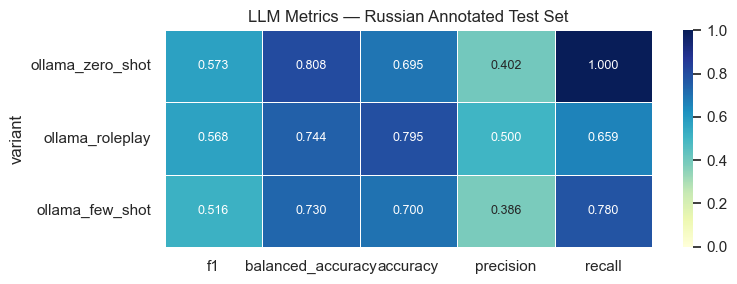

In [9]:
# Metrics heatmap across all LLM variants
if comparison_df is not None and not comparison_df.empty:
    metric_cols = ['f1', 'balanced_accuracy', 'accuracy', 'precision', 'recall']
    hm_df = comparison_df[metric_cols].astype(float)

    fig, ax = plt.subplots(figsize=(8, max(3, len(hm_df) * 0.5)))
    sns.heatmap(hm_df, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax,
                vmin=0, vmax=1, linewidths=0.5, annot_kws={'size': 9})
    ax.set_title('LLM Metrics — Russian Annotated Test Set')
    plt.tight_layout()
    plt.savefig(os.path.join(EVAL_OUT, 'llm_metrics_heatmap.png'), dpi=150)
    plt.show()